In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# Load USCIS quarterly datasets
q1 = pd.read_excel("quarterly_all_forms_fy2025_q1.xlsx", skiprows=3)
q2 = pd.read_excel("quarterly_all_forms_fy2025_q2.xlsx", skiprows=3)
q3 = pd.read_excel("quarterly_all_forms_fy2025_q3.xlsx", skiprows=3)


In [12]:
def extract_totals(df):
    df.columns = df.iloc[0]
    df = df.drop(0)
    
    total = df[df["Category and Form Number"] == "TOTAL"]
    
    approvals = float(total["Approved2"].iloc[0])
    denials = float(total["Denied3"].iloc[0])
    
    return approvals, denials

a1, d1 = extract_totals(q1)
a2, d2 = extract_totals(q2)
a3, d3 = extract_totals(q3)

In [14]:
data = {
    "Quarter": ["Q1", "Q2", "Q3"],
    "Approvals": [a1, a2, a3],
    "Denials": [d1, d2, d3]
}

df = pd.DataFrame(data)
df

,Quarter,Approvals,Denials
0,Q1,2784805.0,273599.0
1,Q2,2396026.0,260768.0
2,Q3,2251593.0,323827.0


In [16]:
df.describe()

,Approvals,Denials
count,3.000000e+00,3.000000
mean,2.477475e+06,286064.666667
std,2.757792e+05,33326.476026
min,2.251593e+06,260768.000000
25%,2.323810e+06,267183.500000
50%,2.396026e+06,273599.000000
75%,2.590416e+06,298713.000000
max,2.784805e+06,323827.000000


In [18]:
df["Approval_Rate"] = df["Approvals"] / (df["Approvals"] + df["Denials"])
df

,Quarter,Approvals,Denials,Approval_Rate
0,Q1,2784805.0,273599.0,0.910542
1,Q2,2396026.0,260768.0,0.901849
2,Q3,2251593.0,323827.0,0.874262


In [20]:
df["Approval_Change"] = df["Approvals"].pct_change()
df["Denial_Change"] = df["Denials"].pct_change()
df

,Quarter,Approvals,Denials,Approval_Rate,Approval_Change,Denial_Change
0,Q1,2784805.0,273599.0,0.910542,NaN,NaN
1,Q2,2396026.0,260768.0,0.901849,-0.139607,-0.046897
2,Q3,2251593.0,323827.0,0.874262,-0.060280,0.241820


In [22]:
df["Approvals"].corr(df["Denials"])

-0.5603741444802461

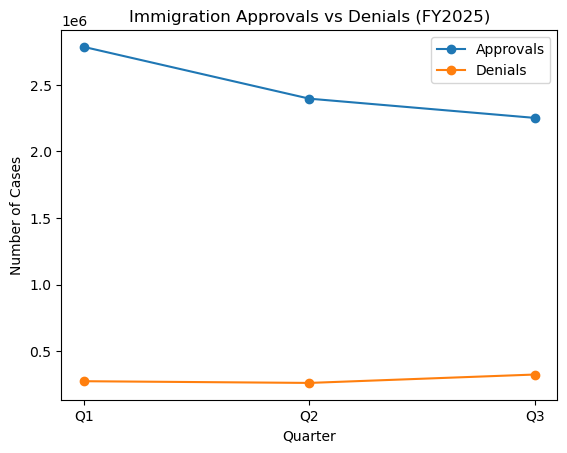

In [24]:
plt.figure()
plt.plot(df["Quarter"], df["Approvals"], marker='o', label="Approvals")
plt.plot(df["Quarter"], df["Denials"], marker='o', label="Denials")

plt.xlabel("Quarter")
plt.ylabel("Number of Cases")
plt.title("Immigration Approvals vs Denials (FY2025)")
plt.legend()

plt.show()

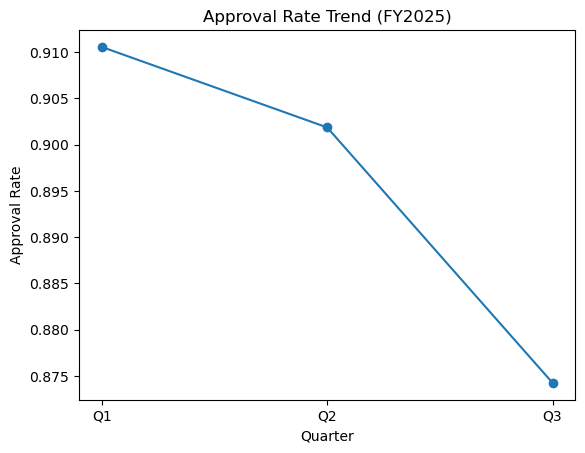

In [26]:
plt.figure()
plt.plot(df["Quarter"], df["Approval_Rate"], marker='o')

plt.xlabel("Quarter")
plt.ylabel("Approval Rate")
plt.title("Approval Rate Trend (FY2025)")

plt.show()

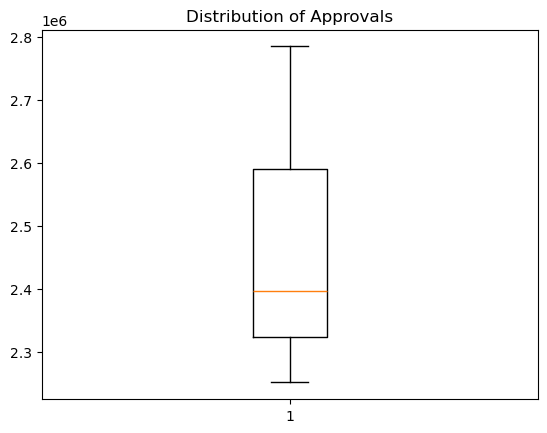

In [28]:
plt.figure()
plt.boxplot(df["Approvals"])
plt.title("Distribution of Approvals")

plt.show()

  Quarter  Approvals   Denials
0      Q1  2784805.0  273599.0
1      Q2  2396026.0  260768.0
2      Q3  2251593.0  323827.0


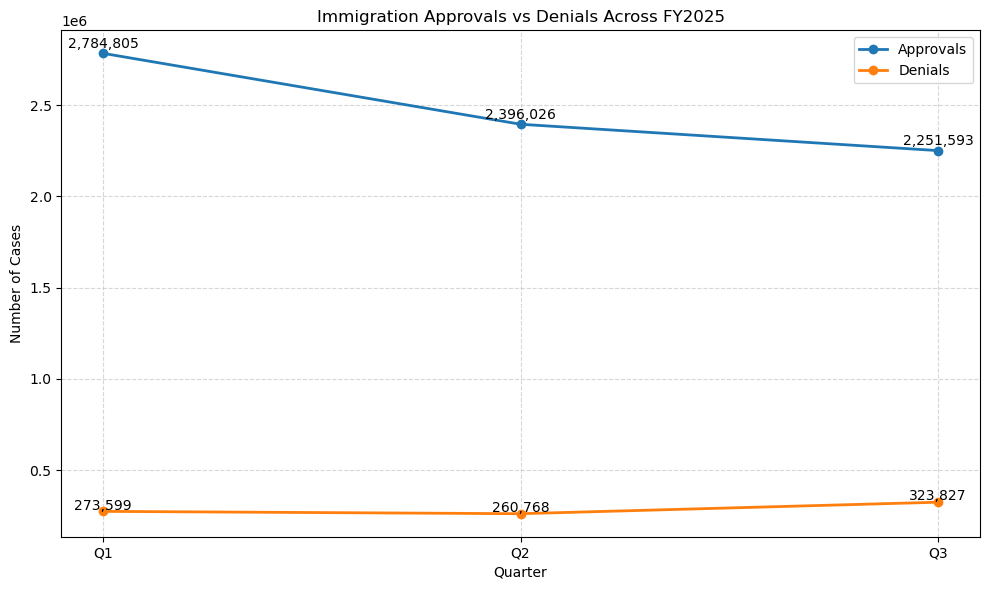

In [30]:
results_df = pd.DataFrame({
    "Quarter": ["Q1", "Q2", "Q3"],
    "Approvals": [a1, a2, a3],
    "Denials": [d1, d2, d3]
})

print(results_df)

# Plot line graph
plt.figure(figsize=(10, 6))
plt.plot(results_df["Quarter"], results_df["Approvals"], marker="o", linewidth=2, label="Approvals")
plt.plot(results_df["Quarter"], results_df["Denials"], marker="o", linewidth=2, label="Denials")

# Add labels to points
for i, row in results_df.iterrows():
    plt.text(row["Quarter"], row["Approvals"] + 30000, f'{int(row["Approvals"]):,}', ha='center')
    plt.text(row["Quarter"], row["Denials"] + 10000, f'{int(row["Denials"]):,}', ha='center')

plt.title("Immigration Approvals vs Denials Across FY2025")
plt.xlabel("Quarter")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

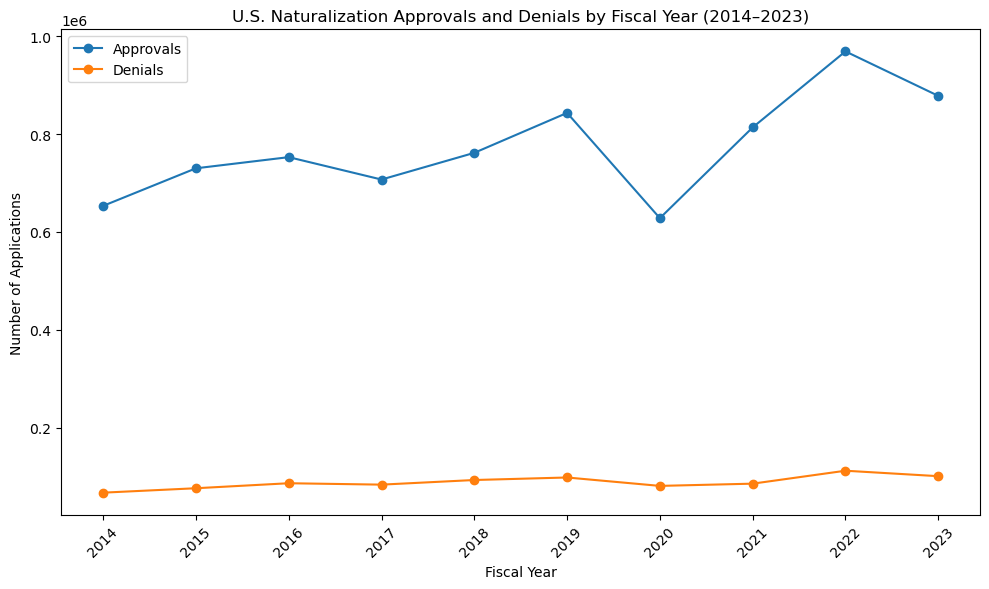

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Fiscal Year": [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    "Approvals": [653416, 730259, 753060, 707265, 761901, 843593, 628254, 813861, 969380, 878460],
    "Denials":   [66767,  75810,  86033,  83176,  92631,  97789,  80609,  85170, 111637, 100490]
})

plt.figure(figsize=(10, 6))
plt.plot(df["Fiscal Year"], df["Approvals"], marker="o", label="Approvals")
plt.plot(df["Fiscal Year"], df["Denials"], marker="o", label="Denials")

plt.title("U.S. Naturalization Approvals and Denials by Fiscal Year (2014–2023)")
plt.xlabel("Fiscal Year")
plt.ylabel("Number of Applications")
plt.xticks(df["Fiscal Year"], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()